In [1]:
# Standard libraries
import warnings
from typing import Tuple, List, Union, Any

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.axes

# Model persistence
import joblib

# Preprocessing & pipelines
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

# Model inspection & interpretability
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from lime.lime_tabular import LimeTabularExplainer
from alibi.explainers import AnchorTabular
import shap

# Warnings
from sklearn.exceptions import InconsistentVersionWarning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

from model import WhiteBox

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- Imbalanced-learn ---
from imblearn.pipeline import Pipeline as ImbPipeline   # pipeline with samplers
from imblearn.base import BaseSampler                   # base class for SMOTE/ADASYN/etc.
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Initialize SHAP visualizations
shap.initjs()


# **It's Jaundice's World, and St. James Hospital is Just Living in It.**

### Authors:  Mariel Concepcion, Lorenzo De Villa, Bingbong Manglicmot, Caitlin Sebastian, JF Viray
### Learning Team: 7
---

# **1. Executive Summary**

Data Monitors created a machine learning model for St. James Hospital’s OB-GYN facility to classify newborns as either at risk or healthy. The system was meant to ease the burden of continuous monitoring and to improve neonatal care. However, in the project's 13th week of use, a newborn was misclassified as healthy and died without timely intervention. A review uncovered at least twelve other misclassifications, exposing systemic flaws. Trust in the algorithm collapsed, disrupting workflow and prompting the hospital to commission an independent audit. The central question became why the model failed and how it could be improved. Our project takes on this case with two goals: first, to understand why the model failed in classifying the 12 at-risk babies, and second, to design a stronger and more reliable replacement.

Our analysis showed that although jaundice levels is indeed a good predictor on the health of the baby, the model leaned too heavily on it. Global explainability tools such as SHAP values, permutation importance, and model coefficients all ranked jaundice far above other features. Partial Dependence Plots confirmed this pattern. As jaundice increased, the probability of being labeled at risk rose above 70%, while heart rate and oxygen saturation peaked at only about 50% and 35%. Feature interaction analysis using Friedman’s H-statistic reinforced this conclusion, showing relatively weak dependencies. The H-statistic between jaundice and oxygen saturation was around 42%, and between jaundice and heart rate bpm around 34%. This indicated that jaundice acted mostly in isolation, which helps explain why the model focused on it so heavily.

Local explainability methods supported the same conclusion. Anchors showed that jaundice is indeed a strong predictor. For instance, a rule such as ```jaundice_level_mg_dl ≤ 4.30``` reliably classified a baby as healthy, achieving 100% precision and roughly 75% coverage. However, further analysis with ICE plots revealed a sigmoid pattern for the jaundice level. Risk stayed low initially and rose sharply with increasing jaundice, and then plateaued near 100%. This implies that jaundice strongly dominates the prediction because small changes near the threshold can drastically change the predicted risk. LIME further highlighted that two otherwise similar babies could be classified differently based solely on jaundice. While jaundice is clearly important, the model’s overreliance created blind spots that could be dangerous in practice.

To correct this, we developed a baseline Random Forest model that spread importance more evenly across features. The new model achieved an F1 score of 99.1% for at-risk babies and an overall F1 score of 99.8%. These results show that careful model design, combined with explainability, can produce both higher performance and greater reliability.

(The project environment is set up with Python version 3.12.8.)

---

# **2. Introduction** 
Data Monitors created a machine learning model for St. James Hospital’s OB-GYN facility with its purpose to classify newborns as either at risk or healthy with the broader goal of easing the burden of continuous monitoring on staff. A complicated occurred when the deployed model produced severe misclassifications. In its thirtieth week of use, the system labeled a newborn as healthy when in fact the baby was at risk, and this mistake resulted in the infant’s death. A subsequent review revealed at least twelve other misclassifications, exposing systemic flaws and causing trust in the algorithm to collapse. 

The problem is that the deployed model systematically misclassified newborns, placing patients at risk and undermining trust in algorithmic decision support. Thus, the main objective of this report is to understand why the system failed in practice and to develop a stronger and more reliable replacement that can be trusted to support medical decision-making.

The case therefore raises urgent questions about what went wrong, how the failure can be explained, and what measures are necessary to ensure that a replacement model will be both accurate and reliable in practice.

Based on this objective, the investigation can be framed around the following key questions:
1. Evaluation Metrics
    * Which metrics are most appropriate for this use case? 
    * Should recall, precision, or a combination of measures be prioritized to evaluate model performance in identifying at-risk newborns?
2. Feature Analysis
    * Which features primarily influenced the model’s predictions for healthy versus at-risk babies? (Global explainability methods can provide a broad overview of feature importance, while local explainability can give concrete examples of individual predictions.)
    * Is there a medical rationale/basis for using these features?
3. Model Improvement
    * How can the model be improved to reduce misclassifications? 
    * Should strategies such as class balancing or feature engineering be applied? 
    * Does the redesigned model correctly classify the previously misclassified babies, and how does it perform overall on both healthy and at-risk populations?


---

# **3. Methodology**

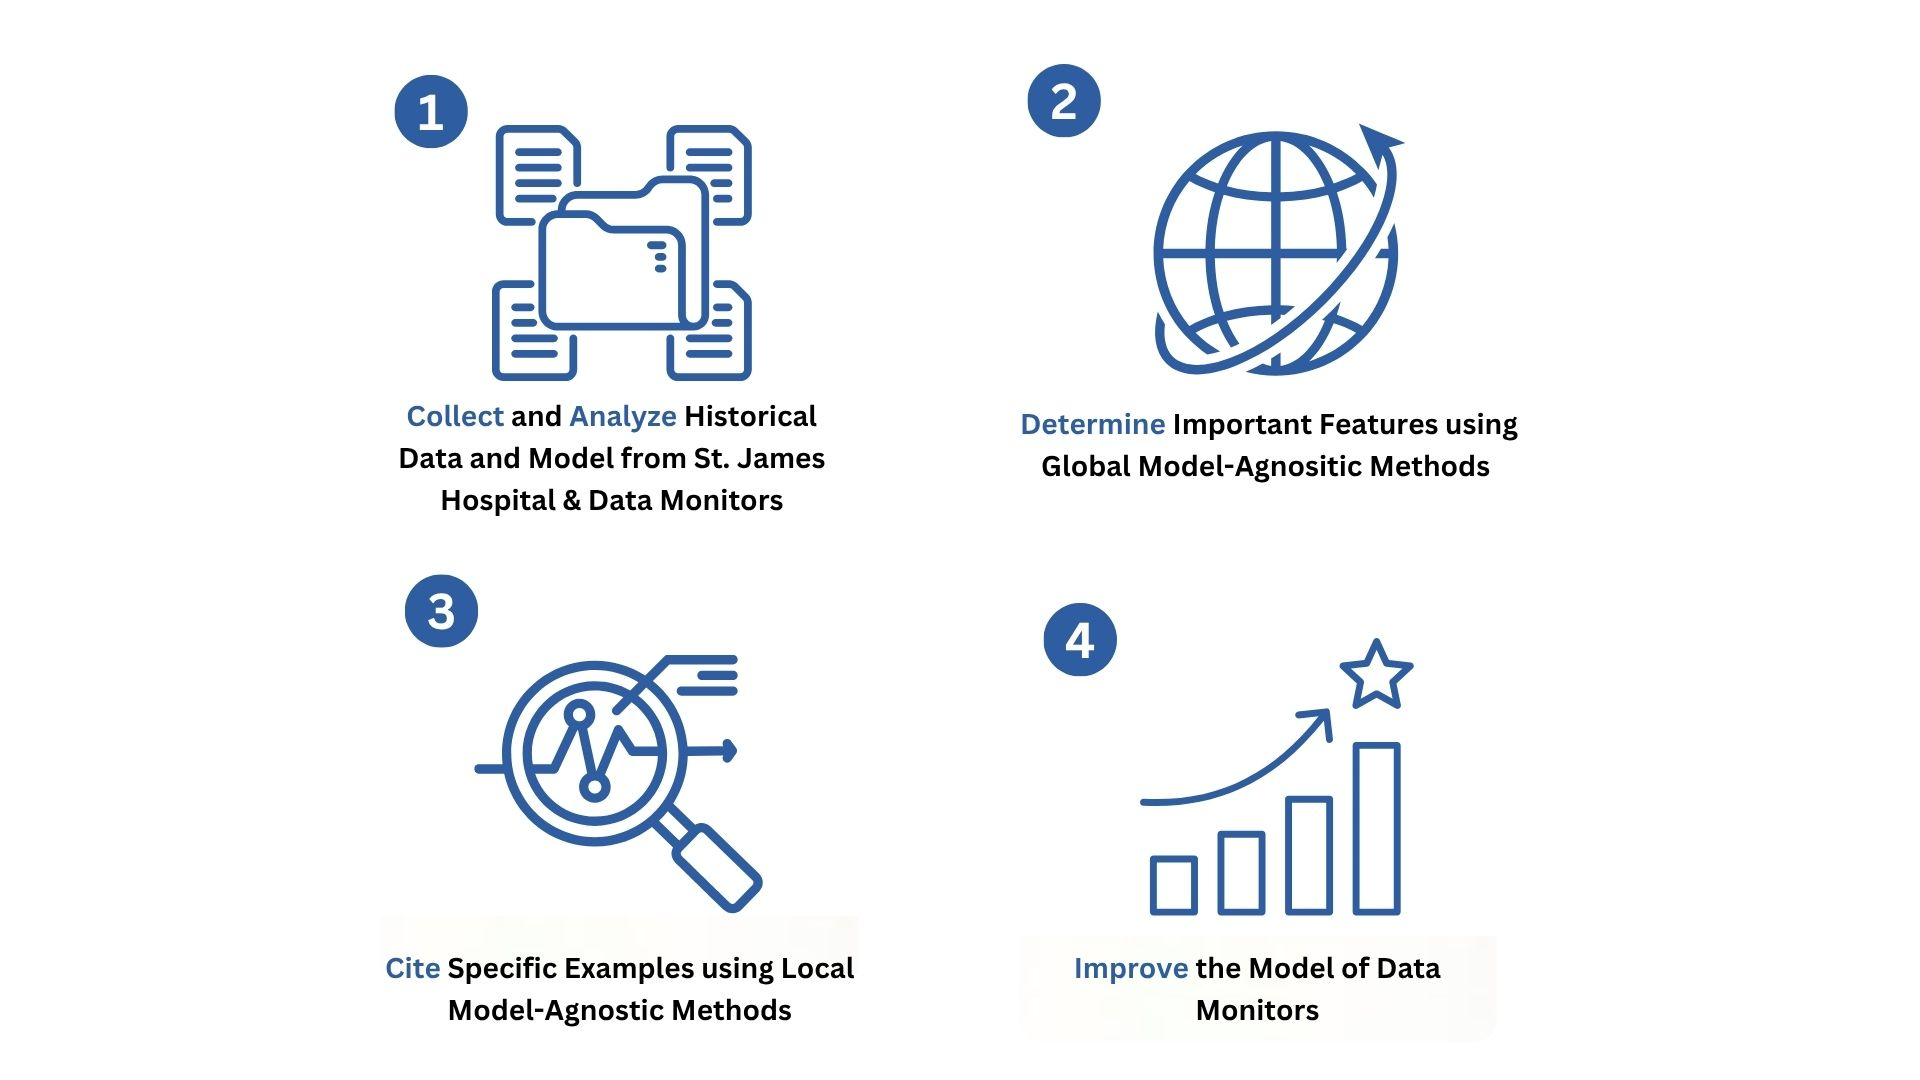


### **3.1 Collect and Analyze Historical Data from Data Monitors**
We first examined the historical dataset provided by St. James Hospital, exploring correlations between features and the target variable. 

### **3.2 Determine Important Features using Global Model-Agnositic Methods**
Global explainability methods were applied to assess feature importance across the entire dataset. Specifically, we used SHAP values, permutation feature importance, and model coefficients to identify which variables the model relied on most heavily when making predictions.

### **3.3 Cite Specific Examples using Local Model-Agnostic Methods**
Local explainability tools were employed to examine individual predictions. Anchors, ICE plots, and LIME were used to provide concrete examples of how the model made decisions for specific babies, highlighting potential blind spots and feature overreliance.

### **3.4 Improve the Model of Data Monitors**
To create a more reliable replacement, we tested multiple modeling approaches while experimenting with different strategies to handle class imbalance between the at-risk and healthy babies. Given the temporal nature of the data, we also incorporated time-series modeling using ARIMA to account for trends and patterns over time that could affect newborn outcomes.


---


# **4. Results and Discussion**

## 4.1 Collect and Analyze Historical Data from Data Monitors

We began by examining the historical dataset provided by Data Monitors to understand feature relationships and class distributions. A pairplot was constructed to see possible relationships between the variables. One key insight emerged from this analysis. Jaundice levels appeared to be a strong predictor of whether a newborn was at risk, as evident even from the histogram distributions (Figure 2). This is medically meaningful because elevated bilirubin levels, which cause jaundice, can indicate liver immaturity or hemolytic disorders in newborns, both of which increase the risk of complications if not managed promptly. 

In [2]:
# Set many of the variables to be used
historical_df = pd.read_csv('data/historical.csv')
misclassified_df = pd.read_csv('data/corrected_false_negatives.csv')

# the model by data monitors as old_model
old_model = joblib.load("data/model.joblib")

In [8]:
# Get processor and classifier from pipeline
processor = old_model["preprocess"]
clf = old_model["clf"]

# Get just the features
feature_names = historical_df.columns[:-1]
X_hist = historical_df[feature_names]

# Get preprocessed X and its feature names
X_preprocessed = processor.transform(X_hist)
preprocessed_feature_names = list(processor.get_feature_names_out())

# Get X and only its features and y where its label encoded
X = historical_df[processor.feature_names_in_]
y = historical_df[historical_df.columns[-1]].map({"Healthy": 0, "At Risk": 1})
y_class = historical_df[historical_df.columns[-1]]
#y = historical_df[historical_df.columns[-1]]

# Get the misclassified babies and their indices
X_hist['orig_index'] = X_hist.index

X_misclassified = X_hist.merge(
    misclassified_df,
    on=['baby_id', 'name', 'gender', 'date'],
    how='inner'
)

# Get the misclassified babies' indices and drop the index column
misclassified_indices = X_misclassified['orig_index'].tolist()
X_misclassified.drop(columns=['orig_index'], inplace=True)
X_hist.drop(columns=['orig_index'], inplace=True)

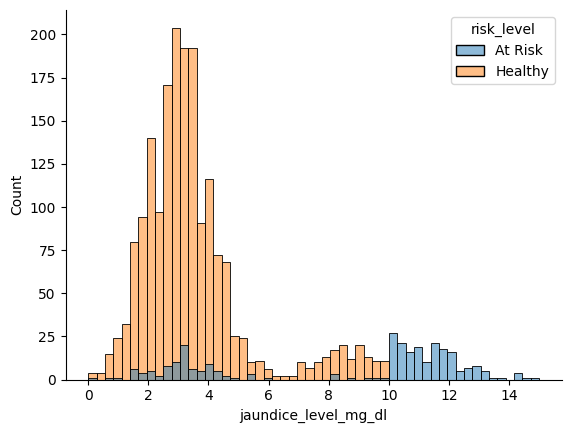

Figure 2. Distribution of Jaundice Levels by Risk Level


In [9]:
sns.histplot(
    data=historical_df,
    x='jaundice_level_mg_dl',
    hue='risk_level'
);

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()
fig_count = 2
print(f'\033[1mFigure {fig_count}\033[0m. Distribution of Jaundice Levels by Risk Level')
fig_count += 1 


## 4.2 Determine Important Features using Global Model-Agnositic Methods

Global explainability methods were applied to identify the features most influential in the model's predictions. SHAP values were used to aggregate individual feature contributions and provide a visual summary of the model’s overall behavior (Figure 3). This analysis revealed that jaundice level, followed by heart rate, were the most critical risk factors. High jaundice values strongly pushed predictions toward 'At Risk,' while a high heart rate and a low oxygen saturation and also contributed to higher risk.

  0%|          | 0/100 [00:00<?, ?it/s]

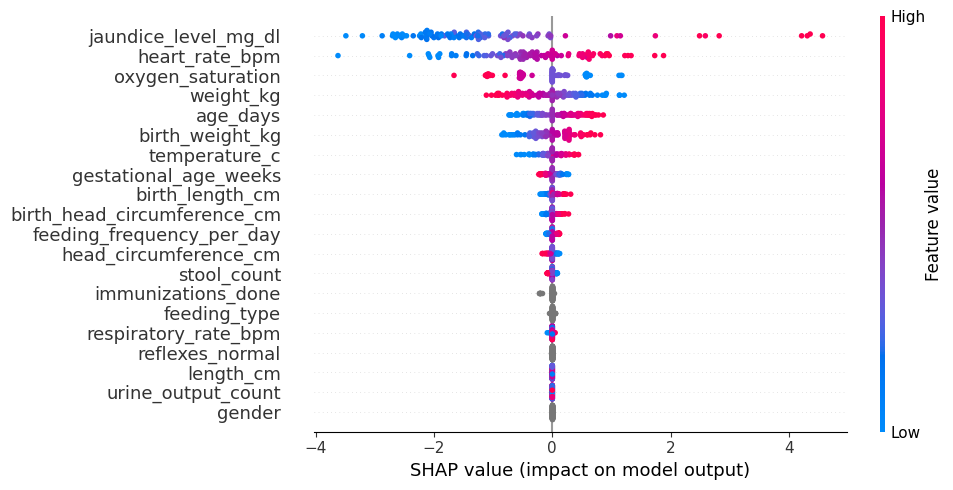

Figure 3. SHAP Summary: Key Drivers of At-Risk Predictions in Newborns


In [5]:
# Use the same X from permutation importance (raw features)
X_for_shap = X.copy()

# Wrap model function to keep DataFrame structure
model_fn = lambda x: old_model.predict_proba(
    pd.DataFrame(x, columns=X_for_shap.columns)
)

# Create KernelExplainer
shap_explainer = shap.KernelExplainer(
    model=model_fn,
    data=shap.sample(X_for_shap, 100, random_state=42),
    feature_names=X_for_shap.columns,
    link="logit"  # since we're predicting probabilities
)

# Compute SHAP values (on a sample for speed)
X_sample = shap.sample(X_for_shap, 100, random_state=42)
shap_values = shap_explainer.shap_values(X_sample)

# Select the class index you want to explain (1 = "At Risk")
class_idx = 1

# Summary plot (same format as your old code)
shap.summary_plot(
    shap_values[:, :, class_idx],
    X_sample,
    plot_size=(10, 5)
)

print(f'\033[1mFigure {fig_count}\033[0m. '
      'SHAP Summary: Key Drivers of At-Risk Predictions in Newborns'
)

fig_count += 1 

Feature importance, which was graphed in Figure 4, was additionally used to verify that the logic of the model aligned with clinical knowledge and with SHAP values. Jaundice emerged as the largest positive predictor, followed by heart rate, birth weight, and age, while lower values of oxygen and weight were associated with increased risk.

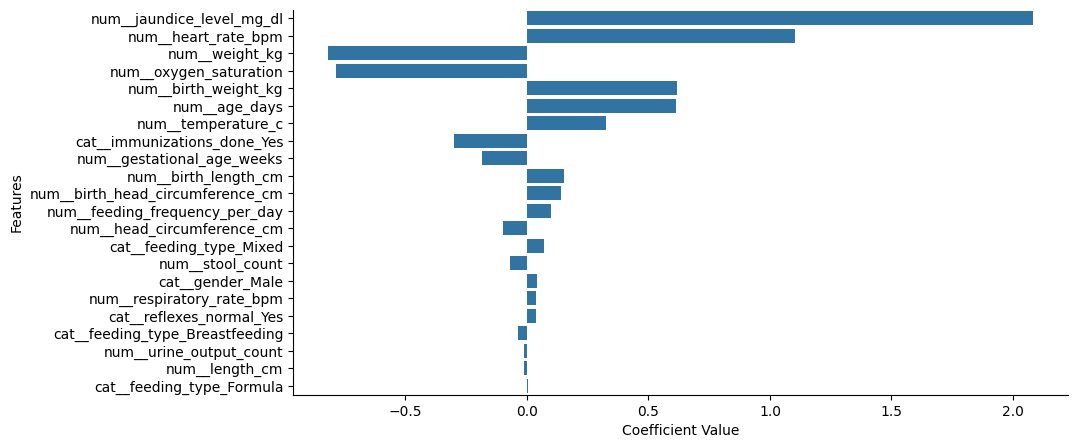

Figure 3. Logistic Regression Feature Importances (Coefficients)


In [10]:
# Get feature importances (coefficients)
feat_imps = clf.coef_[0]  # logistic regression coefficients (1D array)

# Sort by absolute importance (most impactful first)
idx_order = np.argsort(-np.abs(feat_imps))
ordered_imps = np.take_along_axis(feat_imps, idx_order, axis=0)
ordered_labels = np.take_along_axis(np.array(preprocessed_feature_names), idx_order, axis=0)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=ordered_imps, y=ordered_labels)
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Logistic Regression Feature Importances (Coefficients)'
)

fig_count += 1 

As shown in the histogram in Figure 2, it makes sense that jaundice is an important feature due to its clear dividing line between healthy and at-risk babies. However, further analysis revealed that the model relied too heavily on this variable. Using permutation importance, we measured how much each feature affects model performance (Figure 5). In this medical context, recall is especially critical because it captures the model’s ability to avoid False Negatives, which carry the highest risk to patients. Shuffling jaundice led to an approximate 50% drop in recall, while other features had much smaller effects. This demonstrates that the model is heavily reliant on jaundice for its predictions.

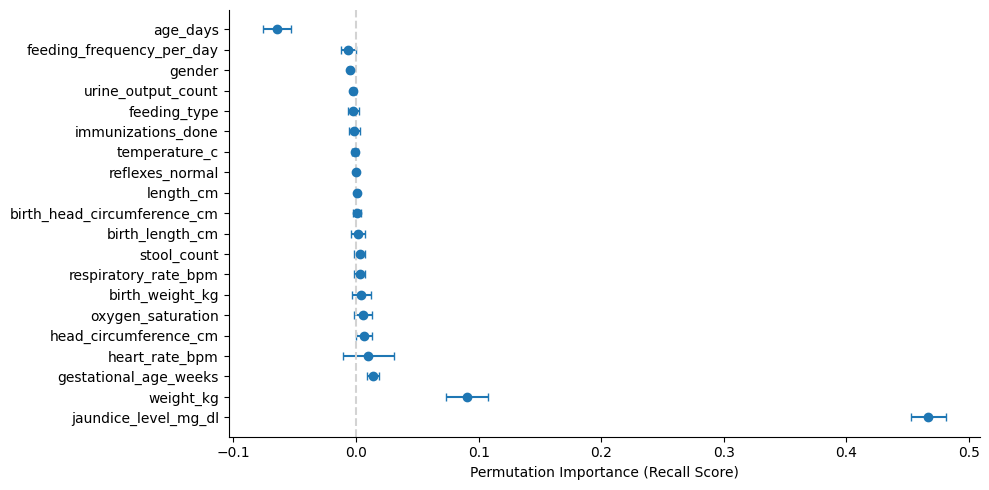

Figure 4. Permutation Importance


In [11]:
# Compute permutation importance on the pipeline
perm_imp = permutation_importance(
    old_model,
    X,
    y,
    scoring="recall",
    random_state=42,
    n_repeats=5
)

# Use raw column names (not preprocessed ones) for interpretability
FEATURE_NAMES = np.array(X.columns)

# Sort by importance
idx_order = np.argsort(-perm_imp.importances_mean)
ordered_means = perm_imp.importances_mean[idx_order]
ordered_stds = perm_imp.importances_std[idx_order]
ordered_labels = FEATURE_NAMES[idx_order]

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(
    x=ordered_means,
    y=ordered_labels,
    xerr=ordered_stds,
    fmt="o",
    capsize=3
)
plt.xlabel("Permutation Importance (Recall Score)")
plt.axvline(0, linestyle="--", c="lightgray")
#plt.title("Permutation Importance (Using Model Features Only)")
plt.tight_layout()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Permutation Importance'
)

fig_count += 1 


Partial Dependence Plots further corroborated this pattern (Figure 6), showing that as jaundice increased, predicted risk probability rose above 70%, while heart rate and oxygen saturation peaked at only 50% and 35%, respectively. Feature interaction analysis using Friedman’s H-statistic reinforced this finding, showing weak dependencies between jaundice and oxygen saturation (42%) and between jaundice and heart rate (34%). This indicates that jaundice acted mostly in isolation, explaining why the model focused on it so heavily.

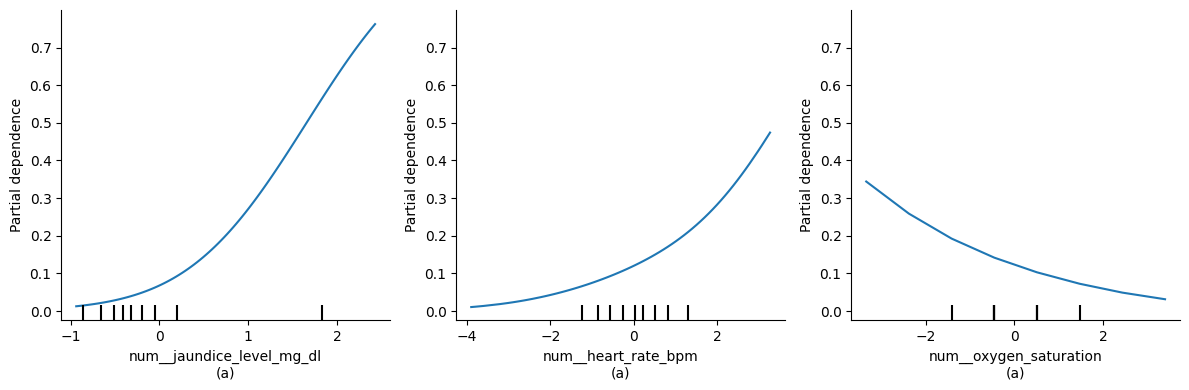

Figure 5. Partial Dependence Plot for Jaundice Level (a), Heart Rate (b), and Oxygen Saturation (c)


In [12]:
selected_features = [
    "num__jaundice_level_mg_dl", 
    "num__heart_rate_bpm", 
    "num__oxygen_saturation"
]

# Get indices of selected features
selected_indices = [list(preprocessed_feature_names).index(f) for f in selected_features]

# Create figure
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Remove top/right spines
for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xlabel(f'{selected_features[i]}\n({chr(97)})')


# Plot PDP
disp = PartialDependenceDisplay.from_estimator(
    clf,
    X_preprocessed,
    features=selected_indices,
    feature_names=preprocessed_feature_names,
    ax=ax
)

plt.tight_layout()
plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Partial Dependence Plot for Jaundice Level (a), '
      'Heart Rate (b), and Oxygen Saturation (c)'
)

fig_count += 1 


In [13]:
def h_statistic(
    model: Union[BaseEstimator, "Pipeline"], 
    X: pd.DataFrame, 
    feat1: str, 
    feat2: str, 
    grid_resolution: int = 20
) -> float:
    """
    Compute Friedman’s H-statistic between two features (feat1, feat2).
    
    Parameters:
    -----------
    model : trained sklearn model or pipeline with predict_proba
    X : pandas DataFrame
        Input features (not yet transformed by preprocessors)
    feat1, feat2 : str
        Names of the two features to compute interaction for
    grid_resolution : int
        How many grid points for PDPs (higher = more accurate, slower)
        
    Returns:
    --------
    float : H-statistic value (0 = no interaction, 1 = pure interaction)
    """
    
    features = [feat1, feat2]
    
    # Joint 2D PDP
    pd_joint = partial_dependence(model, X, features=features,
                                  grid_resolution=grid_resolution,
                                  kind="average")
    pd_joint_values = pd_joint["average"][0]
    
    # Individual PDPs
    pd_feat1 = partial_dependence(model, X, features=[feat1],
                                  grid_resolution=grid_resolution,
                                  kind="average")["average"][0]
    pd_feat2 = partial_dependence(model, X, features=[feat2],
                                  grid_resolution=grid_resolution,
                                  kind="average")["average"][0]
    
    # Reshape for broadcasting
    pd_feat1 = pd_feat1.reshape(-1, 1)
    pd_feat2 = pd_feat2.reshape(1, -1)
    
    # Numerator: variance of interaction effect
    interaction_effect = pd_joint_values - pd_feat1 - pd_feat2
    numerator = np.var(interaction_effect)
    
    # Denominator: variance of joint PDP
    denominator = np.var(pd_joint_values)
    
    h_val = np.sqrt(numerator / denominator) if denominator > 0 else 0.0
    return h_val

def bootstrap_h(
    model: BaseEstimator,
    X: pd.DataFrame,
    feat1: str,
    feat2: str,
    n_boot: int = 50
) -> Tuple[float, np.ndarray]:
    """
    Estimate the H-statistic with bootstrapping to get a confidence interval.

    Parameters
    ----------
    model : sklearn estimator
        Trained model used for computing H-statistic.
    X : pd.DataFrame
        Input features (original, untransformed).
    feat1 : str
        Name of the first feature.
    feat2 : str
        Name of the second feature.
    n_boot : int, default=50
        Number of bootstrap samples.

    Returns
    -------
    Tuple[float, np.ndarray]
        - Mean H-statistic across bootstrap samples.
        - 2.5th and 97.5th percentile confidence interval as a numpy array.
    """
    h_vals: List[float] = []
    n_samples: int = len(X)

    for _ in range(n_boot):
        sample_idx: np.ndarray = np.random.choice(n_samples, n_samples, replace=True)
        X_sample: pd.DataFrame = X.iloc[sample_idx]
        h_vals.append(h_statistic(model, X_sample, feat1, feat2))

    h_vals_array: np.ndarray = np.array(h_vals)
    mean_h: float = h_vals_array.mean()
    ci: np.ndarray = np.percentile(h_vals_array, [2.5, 97.5])

    return mean_h, ci

In [14]:
# Prepare a pipeline for the h_statistic
# Drop unused columns
dropped_columns = ['baby_id', 'name', 'date', 'apgar_score']
X_encoded = X_hist.copy()
X_encoded = X_encoded.drop(columns=dropped_columns)

# Identify categorical features
preprocessor = old_model['preprocess']
categorical_features = preprocessor.transformers_[1][2]  
categorical_indices = [X_encoded.columns.get_loc(col) for col in categorical_features]

# Encode categorical columns as integers
categorical_names = {}
for idx, feature in zip(categorical_indices, categorical_features):
    X_encoded[feature] = X_encoded[feature].astype("category").cat.codes
    categorical_names[idx] = list(X_encoded[feature].astype("category").cat.categories)

# Ensure numeric columns are float
numeric_features = [col for col in X_encoded.columns if col not in categorical_features]
X_encoded[numeric_features] = X_encoded[numeric_features].astype(float)

# ColumnTransformer
recreated_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), preprocessor.transformers_[0][2]),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), preprocessor.transformers_[1][2])
    ],
    remainder='drop'   # drops baby_id, name, date (in case it hasn't been dropped beforehand)
)

recreated_preprocessor.fit(X_encoded)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [54]:
# Have a pipeline for the h_statistic
model_pipeline = Pipeline(steps=[
    ('preprocess', recreated_preprocessor),
    ('clf', old_model['clf'])
])

mean_h_jaundice_oxygen, ci_jaundice_oxygen = bootstrap_h(model_pipeline, X_encoded, 'jaundice_level_mg_dl', 'oxygen_saturation', n_boot=50)
print("H mean between jaundice and oxygen_saturation:", mean_h_jaundice_oxygen, "95% CI:", ci_jaundice_oxygen)

mean_h_jaundice_heart, ci_jaundice_heart = bootstrap_h(model_pipeline, X_encoded, 'jaundice_level_mg_dl', 'heart_rate_bpm', n_boot=50)
print("H mean between jaundice and heart_rate_bpm:", mean_h_jaundice_heart, "95% CI:", ci_jaundice_heart)

mean_h_oxygen_heart, ci_oxygen_heart = bootstrap_h(model_pipeline, X_encoded, 'oxygen_saturation', 'heart_rate_bpm', n_boot=50)
print("H mean between oxygen saturation and heart_rate_bpm:", mean_h_oxygen_heart, "95% CI:", ci_oxygen_heart)

H mean between jaundice and oxygen_saturation: 0.4154514908510257 95% CI: [0.40333153 0.42790493]
H mean between jaundice and heart_rate_bpm: 0.3420242540168123 95% CI: [0.31767777 0.3700021 ]
H mean between oxygen saturation and heart_rate_bpm: 0.3185505599431335 95% CI: [0.30093447 0.33392997]


## 4.3 Cite Specific Examples using Local Model-Agnostic Methods

Local explainability methods were used to provide concrete examples of patterns already identified through global explainability. 

First, we used anchors to find a simple and clear rule. As shown in the table below, if a baby’s jaundice level is $\leq$ 4.30 mg/dL, the model predicts the baby to be healthy (class 0). Whenever this rule applies, the model from Data Monitors is always correct, which is why the precision is 100% and there are no misclassifications. The coverage of 75% means that this rule applies to about three-quarters of all babies, capturing the majority of cases. This shows that a single threshold explains much of the model’s behavior since low jaundice alone is enough for a confident healthy prediction. It also explains why the model relies so heavily on jaundice since it is still a strong and robust feature. However, this reliance becomes problematic when the model begins to overdepend on jaundice, as we will see with LIME and ICE.


In [15]:
# Wrap model prediction for Anchor
def predictor(X):
    baby_df = pd.DataFrame(X, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict(baby_transformed)

explainer = AnchorTabular(
    predictor=predictor,
    feature_names=X_encoded.columns.tolist(),
    categorical_names=categorical_names
)

# Fit on training data
explainer.fit(
    X_encoded.values.astype(np.float64),
    disc_perc=[25, 50, 75]
)

# create a dict
anchors = {}
# Pick an instance to explain
for idx in misclassified_indices:
    anchors[idx] = {}
    instance = X_encoded.iloc[idx].values.reshape(1, -1).astype(np.float64)

    # Generate explanation
    explanation = explainer.explain(instance)

    anchors[idx]['Anchor rule'] = explanation.anchor
    anchors[idx]['Precision'] = explanation.precision
    anchors[idx]['Coverage'] = explanation.coverage

# Convert to DataFrame, making anchors tuples or strings
df_anchors = pd.DataFrame.from_dict(anchors, orient='index')
# convert list to string
df_anchors['Anchor rule'] = df_anchors['Anchor rule'].apply(lambda x: ' & '.join(x))  

# Group by anchor rule and compute median + count
summary = df_anchors.groupby('Anchor rule').agg(
    Precision=('Precision', 'median'),
    Coverage=('Coverage', 'median'),
    Count=('Anchor rule', 'count')  # how often each anchor appears
).sort_values(['Count', 'Precision'], ascending=[False, False])

display(summary.style.format({
    'Precision': "{:.2%}",
    'Coverage': "{:.2%}"
}))


print(f"\033[1mTable 1\033[0m. Summary of Anchor Explanations for Key Features")

,Precision,Coverage,Count
Anchor rule,,,
jaundice_level_mg_dl <= 4.30,100.00%,75.55%,10
jaundice_level_mg_dl <= 3.25,100.00%,49.96%,6
jaundice_level_mg_dl <= 2.50,100.00%,27.40%,3
oxygen_saturation > 98.00,95.61%,14.05%,3
weight_kg > 3.67 & age_days > 8.00,99.45%,41.23%,2
weight_kg > 4.12,96.09%,24.75%,2
temperature_c <= 36.80 & heart_rate_bpm <= 133.00,98.19%,8.27%,1
heart_rate_bpm <= 133.00 & feeding_frequency_per_day <= 8.00,97.28%,8.92%,1
heart_rate_bpm <= 133.00 & oxygen_saturation > 97.00,96.98%,13.40%,1


Table 1. Summary of Anchor Explanations for Key Features


For demonstration purposes, we chose the baby 'Tara' who was wrongly misclassified as healthy. The graphs of individual conditional expectations reveal that jaundice level is the model's dominant feature, capable of driving the predicted risk probability to its maximum of 100% as the level increases. While high heart rate is also strongly correlated with risk, its maximum impact is limited to about 85%; in contrast, oxygen saturation has a weaker, inverse relationship where risk peaks at only 45% at the lowest saturation value shown. This demonstrates a clear hierarchy in feature importance, with jaundice level being the critical factor that dictates the highest potential risk.


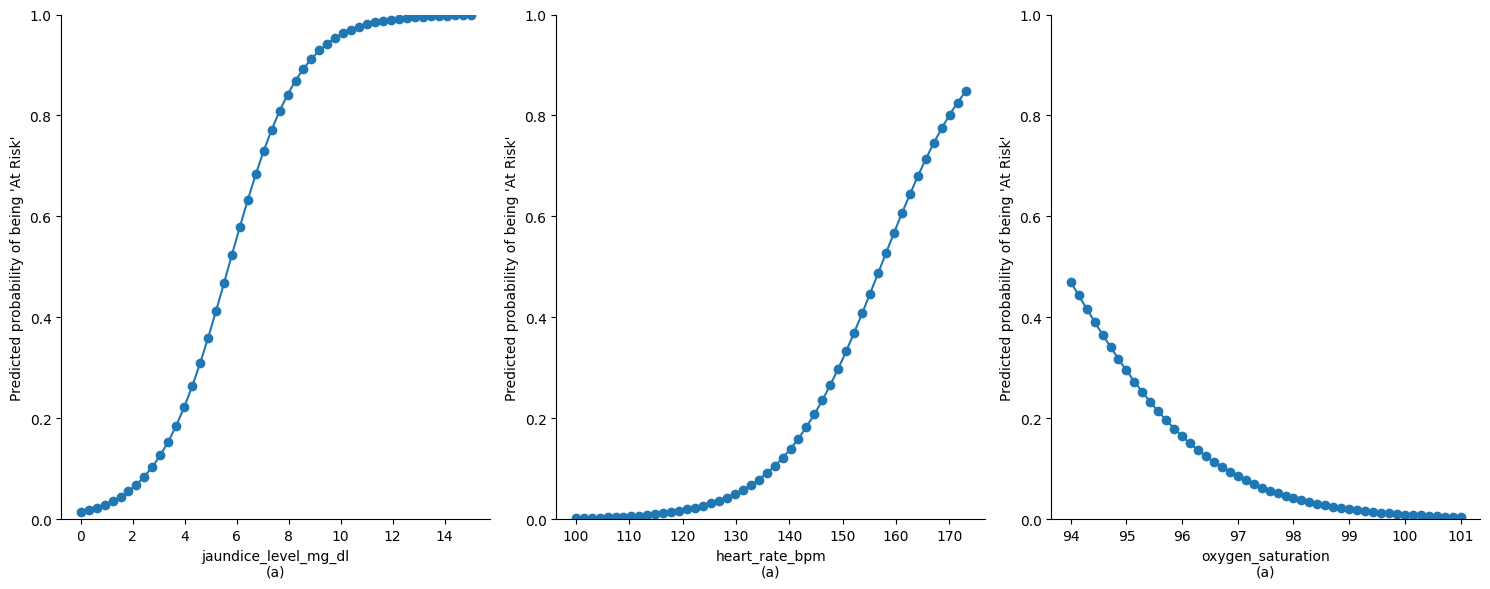

Figure 6. Individual Conditional Expectation for Jaundice Level (a), Heart Rate (b), and Oxygen Saturation (c)


In [16]:
def plot_ice(
    instance: pd.DataFrame,
    feature: str,
    value_range: np.ndarray | List[float] | List[int],
    ax: matplotlib.axes.Axes,
    preprocessor: BaseEstimator | TransformerMixin,  
    model: BaseEstimator, 
    ylim: Tuple[float, float] = (0, 1)
) -> None:
    """
    Plot ICE curve for a single feature on a given instance.
    
    Parameters:
        instance: pd.DataFrame with a single row
        feature: str, feature to vary
        value_range: array-like, values to sweep over
        ax: matplotlib.axes.Axes object
        preprocessor: fitted preprocessing pipeline
        model: trained classifier with predict_proba
        ylim: tuple, y-axis limits
    """
    preds: List[float] = []
    for val in value_range:
        temp: pd.DataFrame = instance.copy()
        temp[feature] = val
        temp_transformed: np.ndarray = preprocessor.transform(temp)
        
        # model.predict_proba returns a numpy array, e.g., [[prob_class_0, prob_class_1]]
        # We take [0, 1] for the probability of class 1
        pred: float = model.predict_proba(temp_transformed)[0, 1]
        preds.append(pred)
    
    # plotting time
    ax.plot(value_range, preds, marker="o")
    #ax.set_xlabel(feature)
    ax.set_ylabel("Predicted probability of being 'At Risk'")
    ax.set_ylim(*ylim)

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# Define features and ranges
misclassified_baby = X_encoded.iloc[[1341]]
selected_features = ['jaundice_level_mg_dl','heart_rate_bpm', 'oxygen_saturation']
features_info = [
    (misclassified_baby, "jaundice_level_mg_dl", np.linspace(0, 15, 50)),
    (misclassified_baby, "heart_rate_bpm", np.linspace(100, 173, 50)),
    (misclassified_baby, "oxygen_saturation", np.linspace(94, 101, 50))
]

# Plot ICE curves
for ax, (instance, feature, value_range), i in zip(axs, features_info, range(3)):
    plot_ice(instance, feature, value_range, ax, recreated_preprocessor, old_model['clf'])
    axs[i].spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(f'{selected_features[i]}\n({chr(97)})')

plt.tight_layout()
plt.show()

print(f'\033[1mFigure {fig_count}\033[0m. '
      'Individual Conditional Expectation for Jaundice Level (a), '
      'Heart Rate (b), and Oxygen Saturation (c)'
)

fig_count += 1 

To show another concrete example of how the model overrelied on jaundice, we used LIME to compare two mostly similar babies. We manually reviewed the misclassified cases and identified the most similar babies, Nicole and Tara. Both had comparable heart rates, oxygen saturation levels, and weight with only minor differences in age in days and body temperature. The primary distinction between them was their jaundice level, with Nicole exhibiting a low jaundice level and Tara a high one. As seen in Figure 8, the model assigned a higher probability of being at risk to Tara (29%) and a lower probability to Nicole (9%), indicating that jaundice was the main factor influencing the model’s confidence in these predictions.


In [17]:
# Create the LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_encoded.values,
    feature_names=X_encoded.columns.tolist(),
    class_names=['Healthy', 'At Risk'],
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    kernel_width=3
)

# Create an anonymous function where given a sample, it predicts using the rf model
def predict_fn(baby):
    baby_df = pd.DataFrame(baby, columns=X_encoded.columns)
    baby_transformed = recreated_preprocessor.transform(baby_df)
    return old_model['clf'].predict_proba(baby_transformed)

for i in [1341, 57]:
    misclassified_baby = historical_df.loc[i]
    print(f"{misclassified_baby['name']} of index {i} "
          f"was misclassified as healthy on {misclassified_baby['date']}")

    exp = explainer.explain_instance(
        X_encoded.iloc[i].values,   # 1D numpy array
        predict_fn,
        num_features=5
    )

    exp.show_in_notebook(show_all=True)

print(f'\033[1mFigure {fig_count}\033[0m. '
      'LIME Explanation of Model Predictions for Two Similar Babies'
)

fig_count += 1 

Tara of index 1341 was misclassified as healthy on 2025-03-15


Nicole of index 57 was misclassified as healthy on 2025-08-24


Figure 7. LIME Explanation of Model Predictions for Two Similar Babies


From both the perspectives of the global and local view, we see that jaundice is indeed clearly a strong predictor. However, the model relied on it too heavily, creating blind spots that were risky in practice.


## 4.4 Improve the model of Data Monitors

In [21]:
# Split data
#y = y.apply(lambda x : 'At Risk' if x == 1 else 'Healthy')
# X_train, X_test, y_train, y_test = train_test_split(X, y_class, stratify=y, test_size=0.2, random_state=42)

# Base model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Initialize WhiteBox
fd = WhiteBox()

# Define sampling strategies
sampling_strategies = {
    "RF Nothing": None,
    "RF SMOTE": SMOTE(random_state=42),
    "RF ADASYN": ADASYN(random_state=42),
    "RF RandomOverSampler": RandomOverSampler(random_state=42),
    "RF RandomUnderSampler": RandomUnderSampler(random_state=42)
}

# Store results
cv_results_summary = {}

for name, sampler in sampling_strategies.items():
    print(f"Running cross-validation with {name}...")
    cv_results = fd.cross_validate_pipeline(
        X=X,
        y=y_class,
        test_model=rf_model,
        sample_strategy=sampler
    )
    # Convert to DataFrame and take mean of train/test scores
    cv_results_summary[name] = pd.DataFrame(cv_results).mean()

# Combine results into a single DataFrame
cv_results_summary_df = pd.DataFrame(cv_results_summary).T

rel_cols = ['test_precision', 'test_recall', 'test_recall_at_risk', 'test_f1']
cv_results_summary_df[rel_cols]

Running cross-validation with RF Nothing...
Running cross-validation with RF SMOTE...
Running cross-validation with RF ADASYN...
Running cross-validation with RF RandomOverSampler...
Running cross-validation with RF RandomUnderSampler...


,test_precision,test_recall,test_recall_at_risk,test_f1
RF Nothing,1.000000,0.989286,0.989286,0.994562
RF SMOTE,0.992792,0.989286,0.989286,0.990991
RF ADASYN,0.996364,0.989286,0.989286,0.992793
RF RandomOverSampler,1.000000,0.989286,0.989286,0.994562
RF RandomUnderSampler,0.921230,0.989286,0.989286,0.952943


In [22]:
from sklearn.ensemble import GradientBoostingClassifier

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y_class, stratify=y, test_size=0.2, random_state=42
# )

# Base model: Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Initialize WhiteBox
fd = WhiteBox()

# Define sampling strategies
sampling_strategies = {
    "GB Nothing": None,
    "GB SMOTE": SMOTE(random_state=42),
    "GB ADASYN": ADASYN(random_state=42),
    "GB RandomOverSampler": RandomOverSampler(random_state=42),
    "GB RandomUnderSampler": RandomUnderSampler(random_state=42)
}

# Store results
cv_results_summary = {}

for name, sampler in sampling_strategies.items():
    print(f"Running cross-validation with {name}...")
    cv_results = fd.cross_validate_pipeline(
        X=X,
        y=y_class,
        test_model=gb_model,        # Use Gradient Boosting model here
        sample_strategy=sampler
    )
    # Convert to DataFrame and take mean of train/test scores
    cv_results_summary[name] = pd.DataFrame(cv_results).mean()

# Combine results into a single DataFrame
cv_results_summary_df = pd.DataFrame(cv_results_summary).T

# Show relevant metrics
rel_cols = ['test_precision', 'test_recall', 'test_recall_at_risk', 'test_f1']
cv_results_summary_df[rel_cols]


Running cross-validation with GB Nothing...
Running cross-validation with GB SMOTE...
Running cross-validation with GB ADASYN...
Running cross-validation with GB RandomOverSampler...
Running cross-validation with GB RandomUnderSampler...


,test_precision,test_recall,test_recall_at_risk,test_f1
GB Nothing,1.000000,0.992857,0.992857,0.996364
GB SMOTE,0.996491,0.989286,0.989286,0.992792
GB ADASYN,0.989831,0.989286,0.989286,0.989344
GB RandomOverSampler,1.000000,0.992857,0.992857,0.996364
GB RandomUnderSampler,0.970476,1.000000,1.000000,0.984613


In [30]:
# --- Python typing ---
from typing import Union, Optional, Dict, Any

# --- Numerical / Data ---
import numpy as np
import pandas as pd

# --- Scikit-learn ---
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.utils.validation import check_is_fitted

# --- Imbalanced-learn ---
from imblearn.pipeline import Pipeline as ImbPipeline  # for handling sampling inside pipeline
from imblearn.base import BaseSampler                  # base class for SMOTE, ADASYN, etc.
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Preprocessing
# If your preprocessor is e.g., a ColumnTransformer or StandardScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Columns for preprocessing
minmax_cols = ['age_days', 'feeding_frequency_per_day', 'urine_output_count', 'stool_count']
standardize_cols = [
    'gestational_age_weeks', 'weight_kg', 'length_cm', 'head_circumference_cm',
    'temperature_c', 'heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation',
    'jaundice_level_mg_dl'
]
categorical_cols = ['gender', 'feeding_type', 'immunizations_done', 'reflexes_normal']


# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), minmax_cols),
        ('standard', StandardScaler(), standardize_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'  # all other columns (unlisted) are automatically dropped
)

class WhiteBox(BaseEstimator, ClassifierMixin):    
    def __init__(self, preprocessor=preprocessor, random_state: int = 39, n_jobs: Optional[int] = None):
        self.random_state = random_state
        self.n_jobs = n_jobs
        self._model_ = RandomForestClassifier(
            n_estimators=500,
            n_jobs=self.n_jobs,
            random_state=self.random_state,
        )
        self.preprocessor = preprocessor
        steps = []
        steps.append(("preprocess", self.preprocessor))
        steps.append(("clf", self._model_)) 
        self.pipeline = ImbPipeline(steps=steps)


    def fit(
        self,
        X: Union[np.ndarray, pd.DataFrame],
        y: Union[np.ndarray, pd.Series],
    ):
        """
        Fit the model using a training X and y.

        Parameters:
        -----------
        X (np.ndarray | pd.DataFrame): The training data
        y (np.ndarray | pd.Sereis): The corresponding targets
        sample_weight (iterable): Sample class weights (default=None)
        """

        self.pipeline.fit(X, y)
        return self

    def predict(self, X: Union[np.ndarray, pd.DataFrame]) -> np.ndarray:
        """Predict the outcome from data X."""
        check_is_fitted(self, "pipeline")
        return self.pipeline.predict(X)

    def fit_predict(
        self, X: Union[np.ndarray, pd.DataFrame], y: Union[np.ndarray, pd.Series]
    ) -> np.ndarray:
        """
        Fit the model using a training X and y, and predict the outcome using
        X. Note that this would give the predicted labels during training.
        """
        return self.fit(X, y).predict(X)
    
    def cross_validate_pipeline(
        self,
        X: Union[np.ndarray, pd.DataFrame],
        y: Union[np.ndarray, pd.Series],
        test_model,
        sample_strategy: Optional[BaseSampler] = None,
        n_splits: int = 5,
        random_state: int = 42,
        n_jobs: int = 1,
    ) -> Dict[str, any]:
        """
        Perform cross-validation on a pipeline that includes preprocessing, 
        optional resampling, and a classifier. Returns training and testing scores 
        for multiple metrics.

        Parameters
        ----------
        X : np.ndarray or pd.DataFrame
            Feature matrix for training and validation.
        y : np.ndarray or pd.Series
            Target vector (binary labels, e.g., 'At Risk' and 'Healthy').
        test_model : estimator object
            The classifier to evaluate. Must follow scikit-learn API (fit/predict).
        sample_strategy : BaseSampler, optional (default=None)
            Optional sampling technique from imbalanced-learn (e.g., SMOTE, ADASYN,
            RandomOverSampler, RandomUnderSampler) to handle class imbalance.
        n_splits : int, default=5
            Number of folds for Stratified K-Fold cross-validation.
        random_state : int, default=42
            Random seed for reproducibility in splitting and sampling.
        n_jobs : int, default=1
            Number of CPU cores to use during cross-validation. -1 uses all cores.

        Returns
        -------
        cv_results : dict
            Dictionary containing training and testing scores for each fold and metric.
            Keys include: 'train_precision', 'test_precision', 'train_recall', 
            'test_recall', 'train_recall_at_risk', 'test_recall_at_risk', 
            'train_recall_healthy', 'test_recall_healthy', 'train_f1', 'test_f1'.
        """
        # Define scorers
        scorers = {
            "precision": make_scorer(precision_score, zero_division=0, average="binary", pos_label="At Risk"),
            "recall": make_scorer(recall_score, zero_division=0, average="binary", pos_label="At Risk"),
            "recall_at_risk": make_scorer(recall_score, zero_division=0, pos_label="At Risk"),
            "recall_healthy": make_scorer(recall_score, zero_division=0, pos_label="Healthy"),
            "f1": make_scorer(f1_score, zero_division=0, average="binary", pos_label="At Risk"),
        }

        # Stratified K-Fold
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

        # Build pipeline
        steps = []
        if self.preprocessor is not None:
            steps.append(("preprocess", self.preprocessor))
        if sample_strategy is not None:
            steps.append(("sampler", sample_strategy))
        steps.append(("clf", test_model))

        pipeline = ImbPipeline(steps=steps)

        # Fit pipeline (optional, not strictly needed for cross_validate)
        pipeline.fit(X, y)

        # Run cross-validation
        cv_results = cross_validate(
            estimator=pipeline,
            X=X,
            y=y,
            cv=skf,
            scoring=scorers,
            n_jobs=n_jobs,
            return_train_score=True
        )

        return cv_results


In [39]:
fd = WhiteBox()

fd.pipeline.fit_predict(X, y)

AttributeError: This 'Pipeline' has no attribute 'fit_predict'

In [35]:
fd.pipeline

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('minmax', ...), ('standard', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


___

# **5. Conclusion and Recommendations** 

___

# **References**

Cheah, P. C. Y., Yang, Y., & Lee, B. G. (2023, September 5). Enhancing financial fraud detection 
through addressing class imbalance using Hybrid smote-gan techniques. MDPI. 
https://www.mdpi.com/2227-7072/11/3/110  

Federal Trade Commission. (2025, March 10). New FTC Data Show a Big Jump in Reported Losses to Fraud to $12.5 Billion in 2024. U.S. Federal Trade Commission. https://www.ftc.gov/news-events/news/press-releases/2025/03/new-ftc-data-show-big-jump-reported-losses-fraud-125-billion-2024

Vedešin, A. (2025). What Are Fraud Detection Rules: Types and Best Practices. Vespia. https://vespia.io/blog/fraud-detection-rules

Wainer, J. (2016). An empirical evaluation of imbalanced data strategies from a practitioner’s point of view (Technical Report 1606.00930). arXiv. Retrieved from https://arxiv.org/abs/1606.00930

Wang, Y. (2025, March 27). A data balancing and Ensemble Learning Approach for credit card 
fraud detection. arXiv.org. https://arxiv.org/abs/2503.21160 

---

# **Supplementary**


## Resampling Strategies

### Oversampling
- Duplicate or generate more minority samples.  
- **Pros:** Keeps all majority data  
- **Cons:** Risk of overfitting  

### Undersampling
- Drop some majority samples.  
- **Pros:** Fast, reduces dataset size  
- **Cons:** Lose information  

---

## Oversampling Techniques

### **SMOTE (Synthetic Minority Oversampling Technique)**
- Create new synthetic samples by interpolating neighbors.  
- Safer than just duplication.  
- **Variants:**
  - **SMOTETomek** = SMOTE + cleaning noisy points  
  - **SMOTEENN** = SMOTE + Edited Nearest Neighbors  
  - **ADASYN** = Adaptive sampling (harder examples get more samples)  

---

### **SMOTEN (Synthetic Minority Over-sampling Technique for Nominal features)**
- **Use case:** When you have **categorical features** (nominal, not ordinal).  
- **Problem:** Standard SMOTE interpolates between numeric features and cannot directly handle categories (e.g., *Red* vs *Blue*).  
- **How it works:**
  - For categorical features → picks the most frequent category among *k*-nearest neighbors.  
  - For numeric features → interpolates as in SMOTE.  
- **Advantage:** Works for **mixed data types** (numeric + categorical).  

---

### **SMOTE-NC (Synthetic Minority Over-sampling Technique for Nominal & Continuous features)**
- **Use case:** Datasets with **both categorical and continuous features**.  
- **Difference from SMOTEN:**
  - SMOTEN → categorical-only  
  - SMOTE-NC → hybrid datasets (categorical + continuous)  
- **How it works:**
  - Continuous features → interpolation  
  - Categorical features → nearest neighbor’s category is chosen (no interpolation)  
- **Advantage:** Can oversample in **mixed datasets** (e.g., fraud detection with `age [numeric]` and `transaction type [categorical]`).  

---

### **ADASYN (Adaptive Synthetic Sampling)**
- **Full name:** ADAptive SYNthetic Sampling  
- **Main idea:** Focuses on harder-to-learn cases near the decision boundary.  
- **How it works:**
  - Identify minority samples with many majority neighbors → “hard” examples.  
  - Generate more synthetic points around these hard examples.  
  - Easier minority samples → fewer synthetic samples.  
- **Advantage:** Creates a **more balanced decision boundary** → model learns rare but important cases.  
- **Disadvantage:** May introduce noise if misclassified points are oversampled too much.  

---

## When to Use Each

- **SMOTEN** → categorical-only datasets  
- **SMOTE-NC** → mixed categorical + continuous datasets  
- **ADASYN** → highly diverse minority examples, focusing on difficult boundary cases  


## **Details on Metrics**
1. Detection Rate
    * This asks, "Out of all transactions, how well does the model is at correctly identifying both fraud and non-fraud overall, where both are equally important?"

2. Fraud Capture Rate
    * This asks, "Out of all the fraud cases, how many did the model actually catch?"

3. Net Value Gained  - 
    * This asks, "How much money does the model helps save (by catching fraud)?"

1. **Detection Rate which is the same as Macro Recall**  
Detection Rate:  

$$
\text{Detection Rate} = \frac{1}{2} \bigg(\frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}} + \frac{TP_{\text{nonfraud}}}{TP_{\text{nonfraud}} + FN_{\text{nonfraud}}} \bigg)
$$

where  
- $n_{\text{fraud}}$ = number of fraud samples  
- $n_{\text{nonfraud}}$ = number of non-fraud samples  
- $N$ = total number of samples  
- $TP_{\text{fraud}}$ = fraud cases correctly identified  
- $FN_{\text{fraud}}$ = fraud cases missed  
- $TP_{\text{nonfraud}}$ = non-fraud cases correctly identified  
- $FN_{\text{nonfraud}}$ = non-fraud cases missed  


2. **Fraud Capture Rate, which is the same as Recall for Fraud Transactions**  

$$
\text{Fraud Capture Rate} = \frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}}
$$  

where  
- $TP_{\text{fraud}}$ = fraud cases correctly identified  
- $FN_{\text{fraud}}$ = fraud cases missed  


3. **Net Value**  

$$
\text{Net Value} = V_{\text{caught}} - V_{\text{innocently flagged}}
$$  

where  
- $V_{\text{caught}}$ = total value of fraud correctly detected 
- $V_{\text{innocently flagged}}$ = total value of fraud incorrectly detected 